In [33]:
import numpy as np
import xarray as xr
import matplotlib as plt

In [42]:
ds1=xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Replots_pH/CESM2/merged_files_biascorrection/ph_CESM2_ssp585_merged_mask.nc')

ds2=xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Replots_pH/CMCC/merged_files_biascorrection/ph_CMCC_ssp585_merged_mask.nc')
ds3=xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Replots_pH/IPSL/merged_files for dwnscaling_ipsl/ph_IPSL_ssp585_merged_mask.nc')
ds4=xr.open_dataset('/media/athira/One Touch/final_datasets/merged files/ph_canesm_ssp585_merged_mask.nc')
ds5=xr.open_dataset('/media/athira/One Touch/final_datasets/merged files/ph_cesm2_org_ssp585_merged_mask.nc')
ds6=xr.open_dataset('/media/athira/One Touch/final_datasets/merged files/ph_gfdl_ssp585_merged_mask.nc')
ds7=xr.open_dataset('/media/athira/One Touch/final_datasets/merged files/ph_mpi-esm-hr_ssp585_merged_mask.nc')
ds8=xr.open_dataset('/media/athira/One Touch/final_datasets/merged files/ph_noresm-mm_ssp585_merged_mask.nc')
ds9=xr.open_dataset('/media/athira/One Touch/final_datasets/merged files/ph_noresm-lm_ssp585_merged_mask.nc')



In [43]:
ds2_interp = ds2.interp(lat=ds1.lat, lon=ds1.lon)
ds3_interp = ds3.interp(lat=ds1.lat, lon=ds1.lon)
ds4_interp = ds4.interp(lat=ds1.lat, lon=ds1.lon)
ds5_interp = ds5.interp(lat=ds1.lat, lon=ds1.lon)#, lev=ds1.lev)
ds6_interp = ds6.interp(lat=ds1.lat, lon=ds1.lon)#, lev=ds1.lev)
ds7_interp = ds7.interp(lat=ds1.lat, lon=ds1.lon)#, lev=ds1.lev)
ds8_interp = ds8.interp(lat=ds1.lat, lon=ds1.lon)#, lev=ds1.lev)
ds9_interp = ds9.interp(lat=ds1.lat, lon=ds1.lon)#, lev=ds1.lev)

ds5_interp = ds5_interp.sel(lev=0, method='nearest')
ds6_interp = ds6_interp.sel(lev=0, method='nearest')
ds7_interp = ds7_interp.sel(lev=0, method='nearest')
ds8_interp = ds8_interp.sel(lev=0, method='nearest')
ds9_interp = ds9_interp.sel(lev=0, method='nearest')

# ds1 = ds1.assign_coords(time=ds2_interp.time)
ds2_interp = ds2_interp.assign_coords(time=ds1.time)
ds3_interp = ds3_interp.assign_coords(time=ds1.time)
ds5_interp = ds5_interp.assign_coords(time=ds1.time)
ds4_interp = ds4_interp.assign_coords(time=ds1.time)
ds6_interp = ds6_interp.assign_coords(time=ds1.time)
ds7_interp = ds7_interp.assign_coords(time=ds1.time)
ds8_interp = ds8_interp.assign_coords(time=ds1.time)
ds9_interp = ds9_interp.assign_coords(time=ds1.time)

In [44]:
ds5_interp#.isel(time=0).ph.plot()

<xarray.Dataset> Size: 62MB
Dimensions:   (time: 1392, lat: 61, lon: 91)
Coordinates:
  * time      (time) object 11kB 1985-01-15 12:00:00 ... 2100-12-15 12:00:00
  * lat       (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
  * lon       (lon) float32 364B 30.12 31.12 32.12 33.12 ... 118.1 119.1 119.9
    lev       float64 8B 0.0
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
Data variables:
    ph        (time, lat, lon) float64 62MB nan nan 8.116 8.113 ... nan nan nan

In [45]:
# all_data=xr.concat([ds1['ph'], ds2_interp['ph'], ds3_interp['ph'], ds4_interp['ph'], ds5_interp['ph'], ds6_interp['ph'], ds7_interp['ph'], ds8_interp['ph'], ds9_interp['ph']],coords='minimal',dim='model')
# all_data


# ens = xr.Dataset({
#     'm1': ds1['ph'],
#     'm2': ds2_interp['ph'],
#     'm3': ds3_interp['ph'],
#     'm4': ds4_interp['ph'],
#     'm5': ds5_interp['ph'],
#     'm6': ds6_interp['ph'],
#     'm7': ds7_interp['ph'],
#     'm8': ds8_interp['ph'],
#     'm9': ds9_interp['ph'],
# })

# standard_dev = ens.to_dataarray(dim='model').std(dim='model')


models = [ds1['ph'], ds2_interp['ph'], ds3_interp['ph'], ds4_interp['ph'],
          ds5_interp['ph'], ds6_interp['ph'], ds7_interp['ph'],
          ds8_interp['ph'], ds9_interp['ph']]

n = len(models)
mean = sum(models) / n
variance = sum((m - mean) ** 2 for m in models) / n   # ddof = 0
standard_dev = variance ** 0.5


In [46]:
# standard_dev=all_data.std(dim='model')

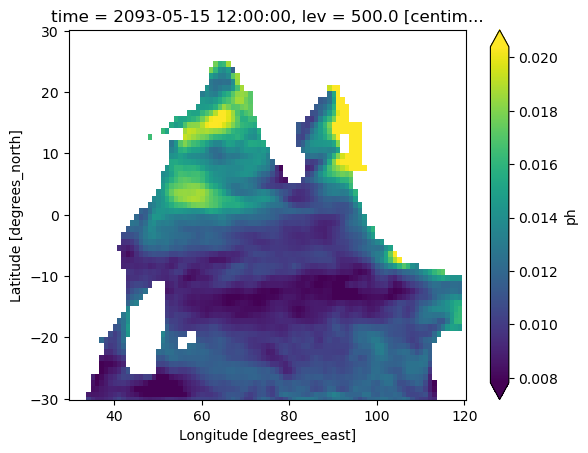

In [47]:
standard_dev[1300].plot(robust=True)

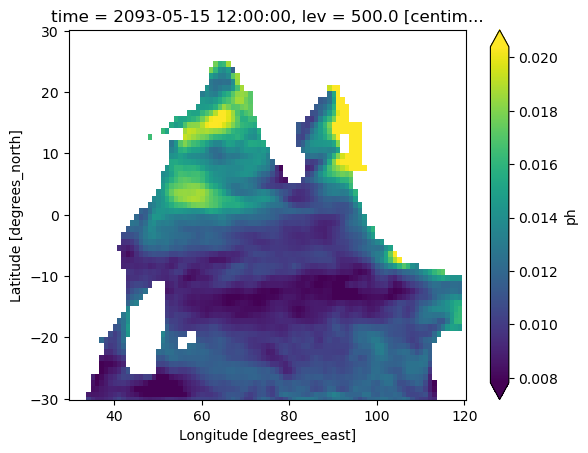

In [48]:
standard_dev[1300].plot(robust=True)

In [49]:
standard_dev.to_netcdf('pH_std of ens models_ssp585_r1.nc')